# Exploratory Data Analysis — Hospital Readmission (Diabetes Dataset)

This notebook explores the UCI Diabetes 130-US Hospitals dataset to understand the features, target distribution, missing values, and key patterns before building a readmission prediction model.

**Target:** `readmitted` — whether a patient was readmitted within 30 days (`<30` → 1), after 30 days (`>30`), or not at all (`NO`).
We treat this as a **binary classification** problem: 1 = readmitted within 30 days, 0 = otherwise.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

DATA_PATH = '../data/raw/dataset_diabetes/diabetic_data.csv'

---
## 1. Load & Preview

In [2]:
# Load data — '?' is used as the missing-value sentinel in this dataset
df = pd.read_csv(DATA_PATH, na_values='?')

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Shape: 101,766 rows × 50 columns


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
df.dtypes

encounter_id                int64
patient_nbr                 int64
race                          str
gender                        str
age                           str
weight                        str
admission_type_id           int64
discharge_disposition_id    int64
admission_source_id         int64
time_in_hospital            int64
payer_code                    str
medical_specialty             str
num_lab_procedures          int64
num_procedures              int64
num_medications             int64
number_outpatient           int64
number_emergency            int64
number_inpatient            int64
diag_1                        str
diag_2                        str
diag_3                        str
number_diagnoses            int64
max_glu_serum                 str
A1Cresult                     str
metformin                     str
repaglinide                   str
nateglinide                   str
chlorpropamide                str
glimepiride                   str
acetohexamide 

---
## 2. Target Variable Analysis

The `readmitted` column has three values:
- `<30` — readmitted in fewer than 30 days (clinical concern, our positive class)
- `>30` — readmitted after 30 days
- `NO`  — not readmitted

We create a **binary target** `readmitted_binary`: 1 if `<30`, 0 otherwise.

In [4]:
# Raw distribution
print('Raw readmitted value counts:')
print(df['readmitted'].value_counts())
print()

# Binary target
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)
print('Binary target distribution:')
print(df['readmitted_binary'].value_counts())
print(f"\nPositive rate (readmitted <30 days): {df['readmitted_binary'].mean():.2%}")

Raw readmitted value counts:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Binary target distribution:
readmitted_binary
0    90409
1    11357
Name: count, dtype: int64

Positive rate (readmitted <30 days): 11.16%


FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/dataset_diabetes/../../../notebooks/figures/01_target_distribution.png'

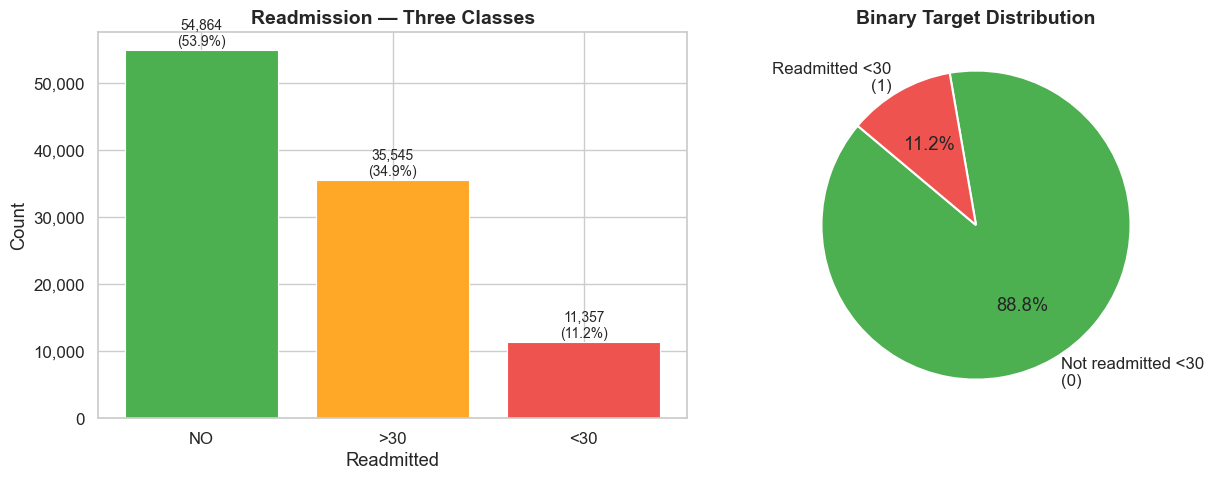

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Raw three-class bar chart ---
raw_counts = df['readmitted'].value_counts()
order = ['NO', '>30', '<30']
colors = ['#4CAF50', '#FFA726', '#EF5350']
axes[0].bar(order, [raw_counts[k] for k in order], color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Readmission — Three Classes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Readmitted')
axes[0].set_ylabel('Count')
for i, k in enumerate(order):
    axes[0].text(i, raw_counts[k] + 200, f'{raw_counts[k]:,}\n({raw_counts[k]/len(df):.1%})',
                 ha='center', va='bottom', fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# --- Binary target pie chart ---
binary_counts = df['readmitted_binary'].value_counts().sort_index()
axes[1].pie(
    binary_counts,
    labels=['Not readmitted <30\n(0)', 'Readmitted <30\n(1)'],
    colors=['#4CAF50', '#EF5350'],
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Binary Target Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/raw/dataset_diabetes/../../../notebooks/figures/01_target_distribution.png',
            bbox_inches='tight', dpi=100)
plt.show()

> **Observation:** The dataset is **imbalanced** — only ~11% of encounters result in a readmission within 30 days. This will need to be addressed during modeling (e.g., class weighting, SMOTE, or threshold tuning).

---
## 3. Missing Values

In this dataset `?` was used as a missing-value placeholder. We already replaced it with `NaN` on load.

In [ ]:
missing = df.isnull().sum()
missing_pct = missing / len(df) * 100
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print(f'Columns with missing values: {len(missing_df)}')
display(missing_df.style.format({'missing_count': '{:,.0f}', 'missing_pct': '{:.2f}%'})
              .background_gradient(subset=['missing_pct'], cmap='Reds'))

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

missing_plot = missing_df[missing_df['missing_pct'] > 0].sort_values('missing_pct')
bars = ax.barh(missing_plot.index, missing_plot['missing_pct'],
               color=sns.color_palette('Reds_r', len(missing_plot)), edgecolor='white')

ax.axvline(x=50, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='50% threshold')
for bar, pct in zip(bars, missing_plot['missing_pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', fontsize=9)

ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Column', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\nHigh-missingness note:")
print("  weight (96%), payer_code (40%), medical_specialty (49%) — likely candidates for drop or imputation.")

---
## 4. Numerical Features

Key numerical features to explore:
- `time_in_hospital` — days patient was hospitalized
- `num_lab_procedures` — number of lab tests performed
- `num_procedures` — number of non-lab procedures
- `num_medications` — number of distinct medications
- `number_diagnoses` — number of diagnoses entered

In [ ]:
num_features = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_diagnoses'
]

df[num_features].describe().T.style.format('{:.2f}').background_gradient(cmap='Blues')

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, feat in enumerate(num_features):
    # Histogram
    axes[0, i].hist(df[feat].dropna(), bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
    axes[0, i].set_title(feat, fontsize=11, fontweight='bold')
    axes[0, i].set_xlabel('Value')
    axes[0, i].set_ylabel('Count')

    # KDE split by target
    for label, color in [(0, '#4CAF50'), (1, '#EF5350')]:
        subset = df[df['readmitted_binary'] == label][feat].dropna()
        subset.plot.kde(ax=axes[1, i], color=color,
                        label='Not <30' if label == 0 else 'Readm <30')
    axes[1, i].set_title(f'{feat}\n(by target)', fontsize=10)
    axes[1, i].set_xlabel('Value')
    axes[1, i].legend(fontsize=8)

fig.suptitle('Numerical Features — Distribution & Target Split', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

> **Observations:**
> - `time_in_hospital` peaks at 1–3 days; patients readmitted within 30 days tend to have slightly longer stays.
> - `num_lab_procedures` is right-skewed with values up to ~130.
> - `num_medications` shows a clear difference between classes — readmitted patients tend to have more medications.

---
## 5. Categorical Features

We examine the key demographic and admission-related categorical variables.

In [ ]:
cat_features = [
    'race', 'gender', 'age',
    'admission_type_id', 'discharge_disposition_id'
]

for feat in cat_features:
    print(f'--- {feat} ---')
    print(df[feat].value_counts())
    print()

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    ax = axes[i]
    vc = df[feat].value_counts().head(15)

    # Color bars by readmission rate
    readm_rates = df.groupby(feat)['readmitted_binary'].mean().reindex(vc.index)
    norm = plt.Normalize(readm_rates.min(), readm_rates.max())
    colors_bar = plt.cm.RdYlGn_r(norm(readm_rates.values))

    bars = ax.bar(range(len(vc)), vc.values, color=colors_bar, edgecolor='white', linewidth=0.6)
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels([str(x) for x in vc.index], rotation=40, ha='right', fontsize=9)
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    # Annotate with readmission rate
    for bar, rate in zip(bars, readm_rates.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vc.values) * 0.01,
                f'{rate:.1%}', ha='center', va='bottom', fontsize=7, color='#333333')

# Hide unused subplot
axes[-1].set_visible(False)

fig.suptitle('Categorical Features (bar color = readmission rate, annotation = <30d rate)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

> **Observations:**
> - Most patients are **Caucasian (75%)**, with African American as the second-largest group.
> - **Age** is concentrated in the 70–90 range — this is an elderly diabetic population.
> - `admission_type_id = 1` (Emergency) is dominant and shows elevated readmission rates.
> - Certain `discharge_disposition_id` values (e.g., discharge to SNF/rehab) correspond to higher readmission risk.

---
## 6. Correlation Analysis

We compute Pearson correlations between numerical features and the binary target.

In [ ]:
# Correlation matrix — numerical features + target
extra_num = ['number_outpatient', 'number_emergency', 'number_inpatient']
corr_cols = num_features + extra_num + ['readmitted_binary']
corr_df = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_df, dtype=bool))

sns.heatmap(
    corr_df,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)

ax.set_title('Pearson Correlation — Numerical Features vs Binary Target',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [ ]:
# Feature-target correlations ranked
target_corr = corr_df['readmitted_binary'].drop('readmitted_binary').sort_values(key=abs, ascending=False)
print('Correlation with readmitted_binary (ranked by absolute value):')
print(target_corr.to_string())

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

colors_corr = ['#EF5350' if v > 0 else '#42A5F5' for v in target_corr.values]
bars = ax.barh(target_corr.index, target_corr.values, color=colors_corr, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r')
ax.set_title('Feature Correlation with Target (readmitted <30d)', fontsize=13, fontweight='bold')

for bar, val in zip(bars, target_corr.values):
    offset = 0.002 if val >= 0 else -0.002
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha=ha, fontsize=9)

plt.tight_layout()
plt.show()

---
## 7. Key Findings

### Summary of EDA

| Area | Finding |
|---|---|
| **Dataset size** | ~101,000 encounters, 50 features |
| **Class imbalance** | Only ~11% of patients are readmitted within 30 days → needs class-balancing strategy |
| **Missing data** | `weight` is missing in 96% of rows (drop); `medical_specialty` (~49%) and `payer_code` (~40%) are also heavily missing |
| **Population** | Elderly diabetic patients (age 70–90 dominant), mostly Caucasian, majority Emergency admissions |
| **Strongest predictors** | `number_inpatient` (prior inpatient visits) shows the highest positive correlation with early readmission; `number_outpatient` is negatively correlated |
| **Medication load** | Higher `num_medications` correlates with readmission — complex patients are at greater risk |
| **Stay length** | `time_in_hospital` has a positive (but weak) correlation with readmission |
| **Multicollinearity** | `num_medications` and `num_lab_procedures` are moderately correlated (~0.45) — may need VIF check |

### Next Steps (Feature Engineering — Notebook 02)
1. **Drop** `weight`, `payer_code`, `encounter_id`, `patient_nbr`
2. **Encode** categorical variables (age brackets → ordinal, race/gender → one-hot)
3. **Engineer** a `prior_visits` composite (inpatient + outpatient + emergency)
4. **Handle** `diag_1/2/3` — group ICD-9 codes into clinical categories
5. **Scale** numerical features for models sensitive to magnitude (logistic regression, SVM)
6. **Address imbalance** with SMOTE or class_weight in model training